# Evaluation of Low-Pass Filter RNN
## Model loading

In [2]:
from model import LowpassRNN
import torch
from pathlib import Path
import numpy as np
import os

In [3]:
hidden_size = 128
num_layers = 2
buffer_size = 4096
sample_rate = 48000
checkpoint_folder = "checkpoints-8"
dataset_folder = "dataset-1"
dataset_size = 599

In [3]:
state = torch.load(
    "holigrail_butter_lp_3/best.pt",
    map_location=torch.device("cpu")
)
# Strip the _orig_mod. prefix added by torch.compile
state_dict = {
    k.replace("_orig_mod.", ""): v for k, v in state["model_state_dict"].items()
}

filter_rnn = LowpassRNN(hidden_size, num_layers)
filter_rnn.load_state_dict(state_dict)
filter_rnn.eval()

LowpassRNN(
  (gru): GRU(2, 128, num_layers=2, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

### Test model with known data

In [13]:
from create_dataset import normalize_freq
def run_inference(
    model: LowpassRNN,
    input: np.ndarray,
    fc_norm: float,
    buffer_size: int,
    sample_rate: int,
) -> np.ndarray:
    """
    Args:
        model:       trained LowpassRNN
        input:       raw audio signal of length N, where N is a multiple of buffer_size
        fc_norm:     normalized cutoff frequency (2 * cutoff_freq / sample_rate)
        buffer_size: must match the buffer_size used during training
        sample_rate: must match the sample_rate used during training
    Returns:
        filtered signal of length N
    """
    model.eval()

    n_buffers = len(input) // buffer_size
    output_buffers = []
    hidden = None

    with torch.no_grad():
        for i in range(n_buffers):
            buffer = input[i * buffer_size : (i + 1) * buffer_size]
            x = torch.from_numpy(buffer).float()  # (buffer_size,)
            fc_channel = torch.full((buffer_size,), fc_norm)
            x = torch.stack([x, fc_channel], dim=-1).unsqueeze(0)  # (1, buffer_size, 2)
            output, hidden = model(x, hidden)

            # .cpu() handles both CUDA and CPU tensors safely before .numpy()
            output_buffers.append(output.squeeze().cpu().numpy())  # (buffer_size,)

    return np.concatenate(output_buffers)  # (N,)

In [ ]:
from random import randint

data_idx = randint(0, dataset_size)
x = np.load(os.path.join(dataset_folder, "inputs/input-{}.npy".format(data_idx)))
y = np.load(os.path.join(dataset_folder, "expected/expected-{}.npy".format(data_idx)))
print("Sample {}".format(data_idx))

y_pred = run_inference(
    filter_rnn, x[:-1], fc_norm=x[-1], buffer_size=buffer_size, sample_rate=sample_rate
)

In [ ]:
import matplotlib.pyplot as plt

print(x.shape)
print(y.shape)
print(y_pred.shape)
t = np.arange(len(y))
plt.figure()
plt.plot(t, x[:-1], label="signal")
plt.plot(t, y, label="filtered signal")
plt.plot(t[:min(len(t), len(y_pred))], y_pred, label="predicted filtered signal")
plt.legend(loc="lower left")
plt.show()

### Test model with unknown data

In [ ]:
from create_dataset import lowpass_filter
import colorednoise as cn

cutoff_freq = 250 # Hz
length = 2 # seconds

buffer_amount_in_length = (length * sample_rate) // buffer_size
N = buffer_amount_in_length * buffer_size
beta = 0  # the exponent: 0=white noite; 1=pink noise;  2=red noise (also "brownian noise")

brown_noise = cn.powerlaw_psd_gaussian(beta, N)
filtered_noise = lowpass_filter(brown_noise, cutoff_freq, sample_rate)

fc_norm = normalize_freq(cutoff_freq, sample_rate)

pred = run_inference(filter_rnn, brown_noise, fc_norm, buffer_size, sample_rate)


In [ ]:
t = np.arange(len(pred))
plt.figure()
# plt.plot(t, brown_noise, label="signal")
plt.plot(t, filtered_noise, label="filtered signal")
plt.plot(t, pred, label="predicted filtered signal", linestyle="dotted", alpha=.7)
plt.legend(loc="lower left")
plt.show()

In [ ]:
from create_dataset import generate_log_sweep, cut_to_nearest_multiple

cutoff_freq = 50  # Hz
length = 2  # seconds

sweeps, fsweeps = generate_log_sweep(sample_rate, 20, 7500, 1.1, cutoff_freq)

print(len(sweeps))

fc_norm = normalize_freq(cutoff_freq, sample_rate)

sweeps = cut_to_nearest_multiple(sweeps, buffer_size)
fsweeps = cut_to_nearest_multiple(fsweeps, buffer_size)
pred_fsweeps = run_inference(filter_rnn, sweeps, fc_norm, buffer_size, sample_rate)

t = np.arange(len(pred_fsweeps))

In [ ]:
plt.figure()
# plt.plot(t, sweeps, label="signal")
plt.plot(t, fsweeps, label="filtered signal")
plt.plot(t, pred_fsweeps, label="predicted filtered signal", linestyle="dotted")
plt.legend(loc="lower left")
plt.show()

Interestingly enough, the RNN model seems to have a steeper slope than the filter it learned from for lower cutoff frequencies.

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

# method from https://dsp.stackexchange.com/a/73993/91311

def demod_signal(time : np.ndarray, signal : np.ndarray, frequency : float) -> np.ndarray:
    x = np.cos(2 * np.pi * frequency * time) - 1j * np.sin(2 * np.pi * frequency * time)
    return signal * x


def signal_gain_at_f(
    time: np.ndarray, signal: np.ndarray, frequency: float
) -> np.ndarray:
    z = demod_signal(time, signal, frequency)
    avg_z = np.average(z)
    return 2 * np.absolute(avg_z)


def filter_gains(
    frequencies: np.ndarray,
    buffer_size: int,
    buffer_count: int,
    filter_for_fc: callable,
    fc_hertz: float,
    sample_rate: float = 48000,
):
    def process_freq(freq):
        p = sample_rate / freq
        m = (buffer_count * buffer_size) // p
        t = np.linspace(0, m / freq, buffer_size * buffer_count)
        input_signal = np.cos(2 * np.pi * freq * t)
        signal = filter_for_fc(input_signal, fc_hertz)
        return signal_gain_at_f(t, signal, freq)

    return Parallel(n_jobs=-1)(delayed(process_freq)(freq) for freq in frequencies)


def plot_bode_so(
    model: LowpassRNN,
    cutoff_freq: float,
    buffer_size: int,
    sample_rate: int,
    n_freqs: int = 100,
    buffer_count : int = 10
) -> None:
    def iir_gru(input_signal : np.ndarray, fc_hertz : float):
        output = run_inference(
            model, input_signal, normalize_freq(fc_hertz, sample_rate), buffer_size, sample_rate
        )
        return output
    
    freqs = np.geomspace(20, 20000, n_freqs)  # log-spaced, 20Hz to Nyquist
    gains = filter_gains(
        freqs, buffer_size, buffer_count, iir_gru, cutoff_freq, sample_rate=sample_rate
    )
    magnitudes_db = 20 * np.log10(np.array(gains) + 1e-8)
    from scipy.signal import freqz, butter

    b, a = butter(1, 2 * cutoff_freq/ sample_rate, btype="low", analog=False)
    w, h = freqz(b, a, worN=freqs, fs=sample_rate)
    reference_db = 20 * np.log10(np.abs(h) + 1e-8)

    plt.figure(figsize=(10, 5))
    plt.semilogx(freqs, magnitudes_db, label="RNN filter")
    plt.semilogx(w, reference_db, "--", label="Reference Butterworth")
    plt.axvline(cutoff_freq, color="r", linestyle=":", label=f"fc = {cutoff_freq} Hz")
    plt.axhline(-3, color="gray", linestyle=":", label="-3 dB")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude (dB)")
    plt.title(f"Bode Magnitude Plot (steady-state) — fc = {cutoff_freq} Hz")
    plt.legend()
    plt.grid(True, which="both")
    plt.tight_layout()
    plt.show()


100


/tmp/ipykernel_302947/3001171314.py:30: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


250
750
1000
5000


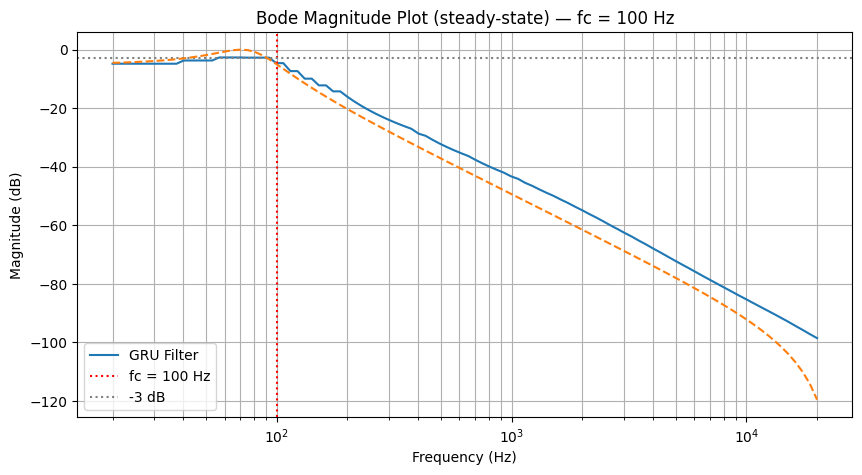

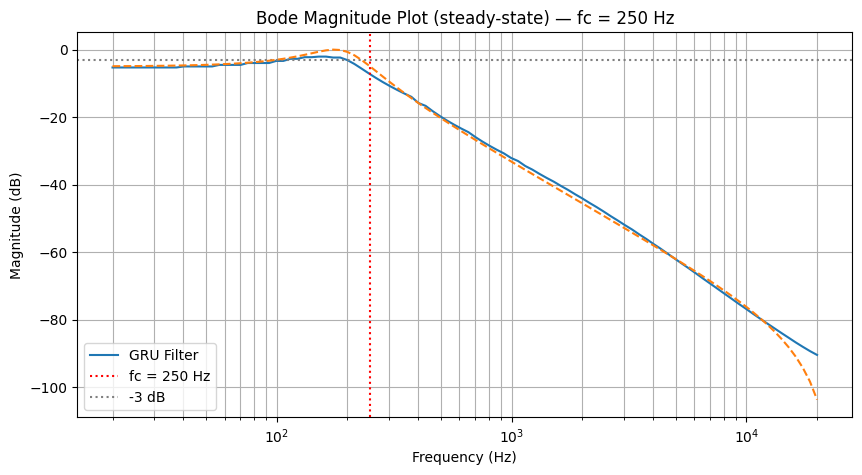

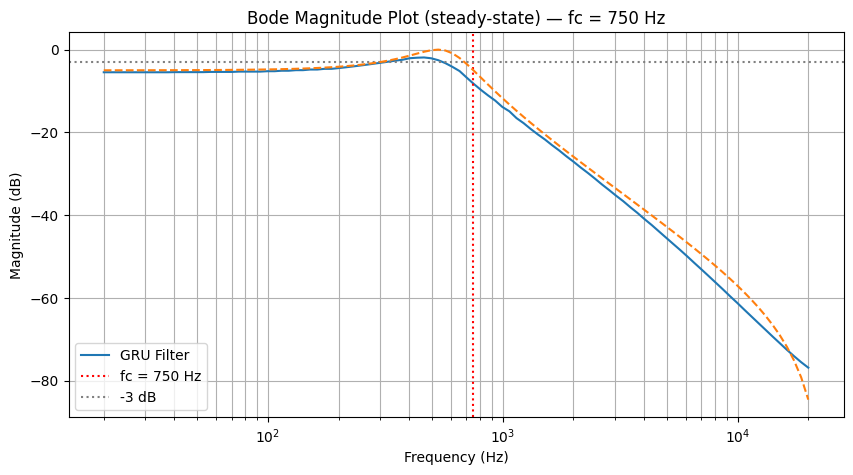

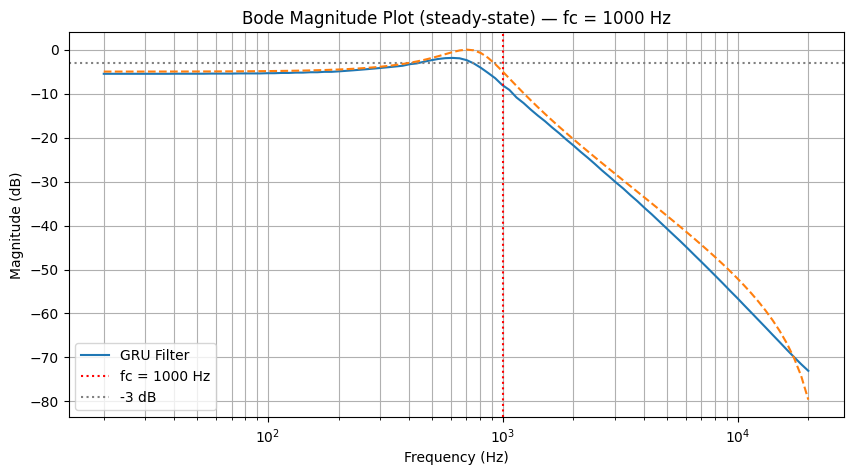

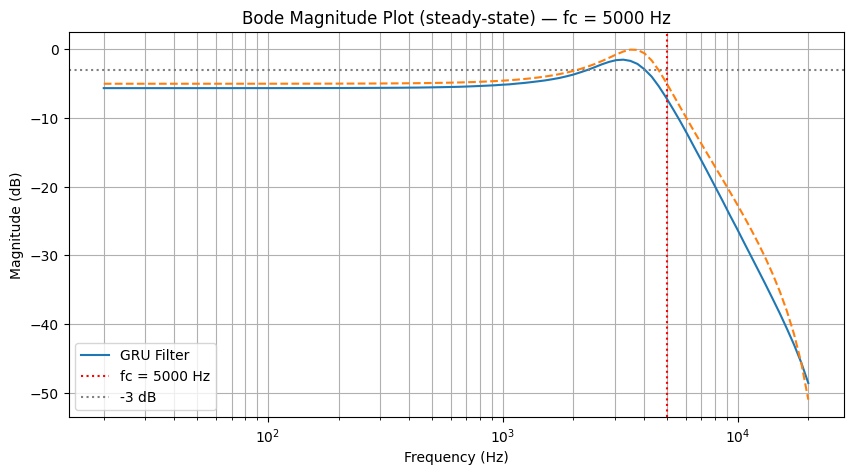

In [120]:
import torch
import importlib
import analysis_tools as at
importlib.reload(at)
hidden_size = 128
num_layers = 2
buffer_size = 256
sample_rate = 48000
checkpoint_folder = "checkpoints-8"
dataset_folder = "dataset-1"
dataset_size = 599

state = torch.load(
    "cheby1_lp_2_bfs_1024/best.pt", map_location=torch.device("cpu")
)
# Strip the _orig_mod. prefix added by torch.compile
state_dict = {
    k.replace("_orig_mod.", ""): v for k, v in state["model_state_dict"].items()
}

filter_rnn = LowpassRNN(hidden_size, num_layers)
filter_rnn.load_state_dict(state_dict)
filter_rnn.eval()
order = 2
for fc in [100, 250, 750, 1000, 5000]:
    print(fc)
    # plot_bode_so(filter_rnn, fc, buffer_size, sample_rate, buffer_count=50)
    fig, axes = at.plot_bode_GRU(filter_rnn, fc, buffer_size, sample_rate, show=False)
    at.plot_cheby_into(axes, fc, order, 5, sample_rate)
    fig.show()

100


/home/grybouilli/projects/android_playground/lowpass_filter_nn/analysis_tools.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  
/tmp/ipykernel_21467/1108257907.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/tmp/ipykernel_21467/1108257907.py:37: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


256
750
1000
5000


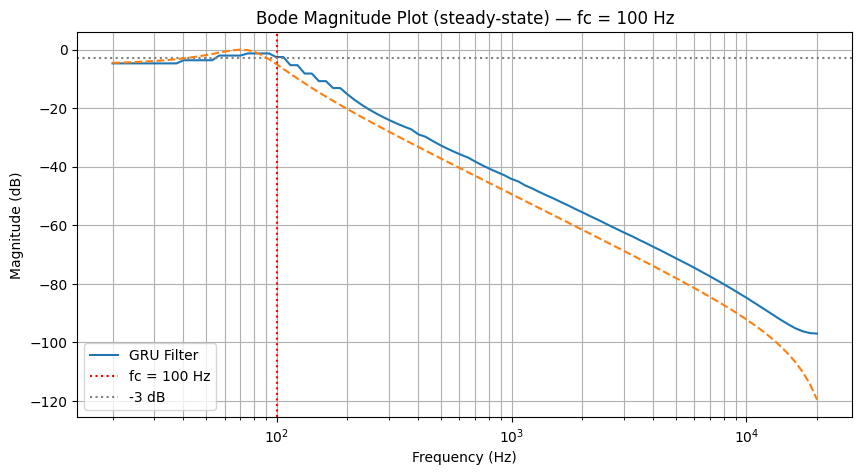

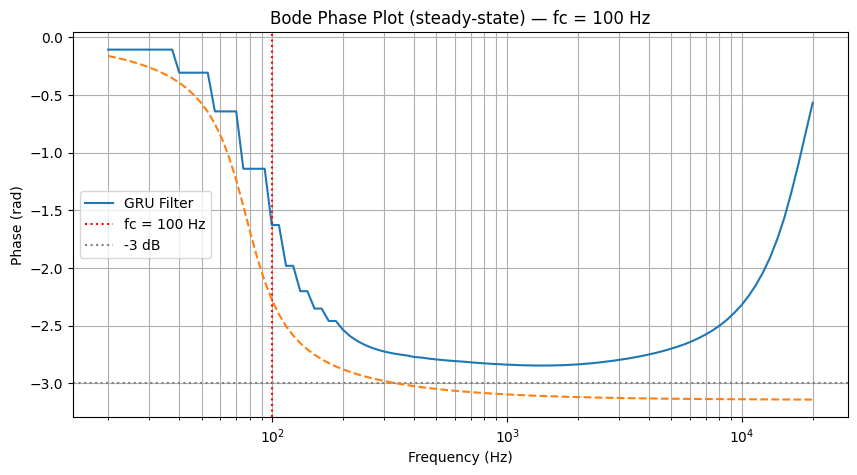

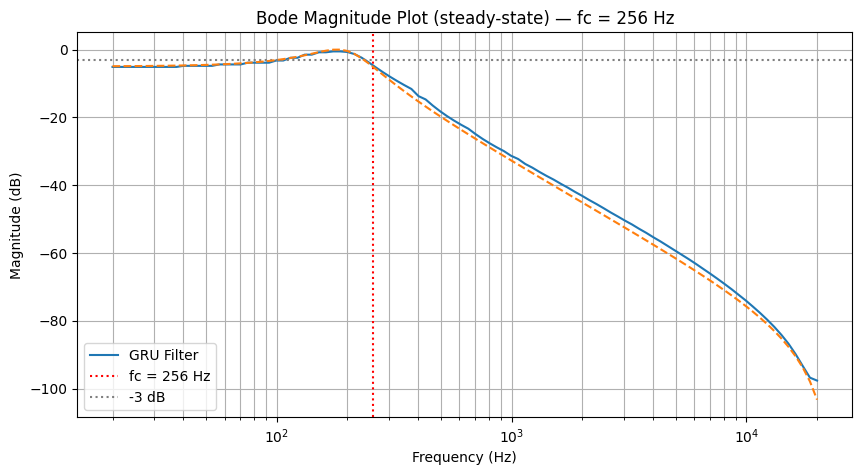

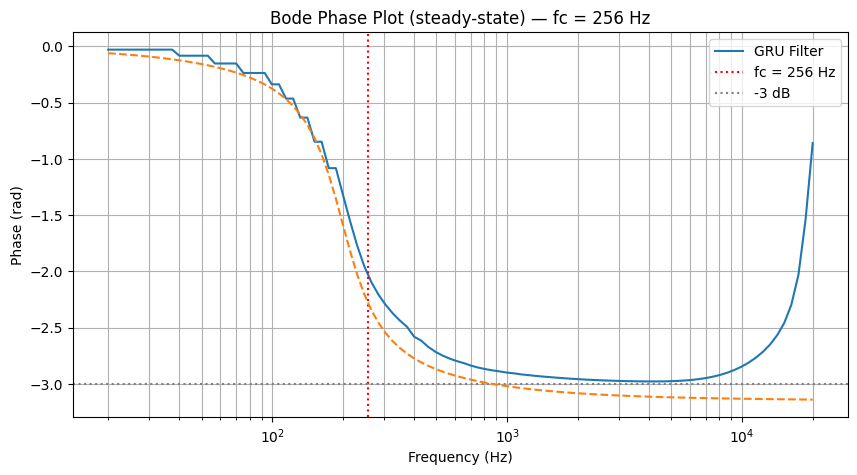

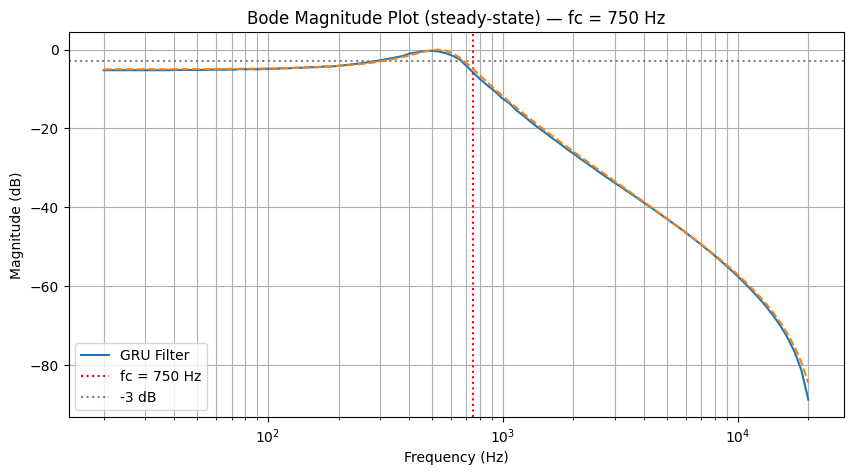

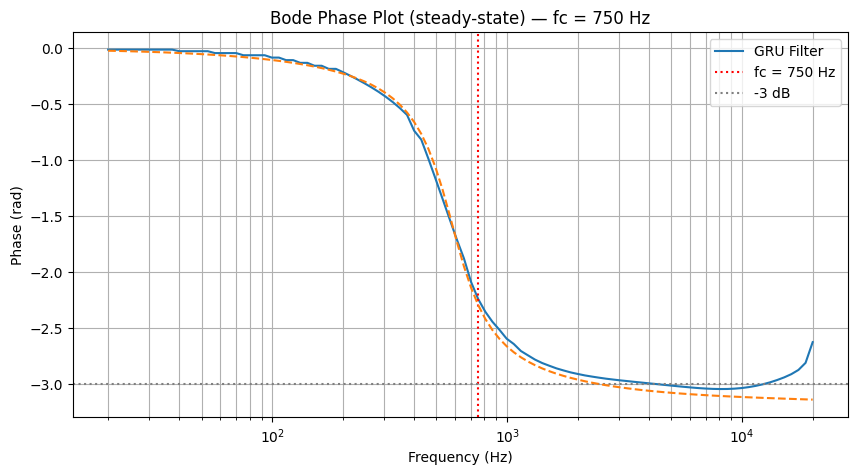

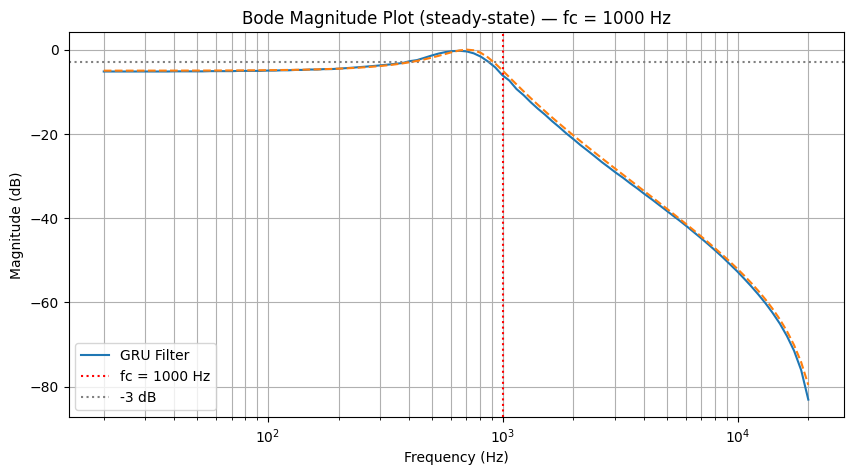

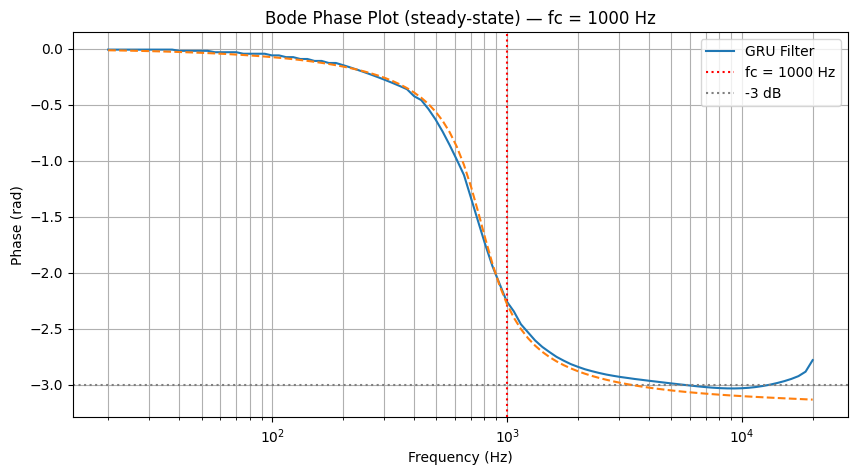

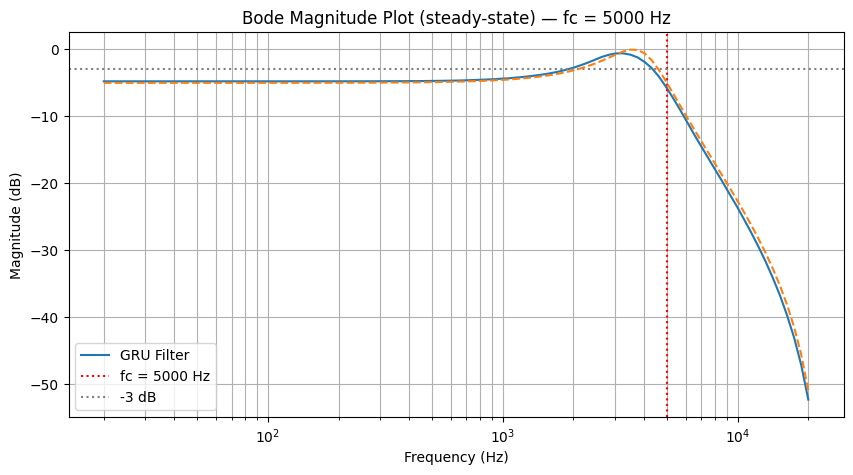

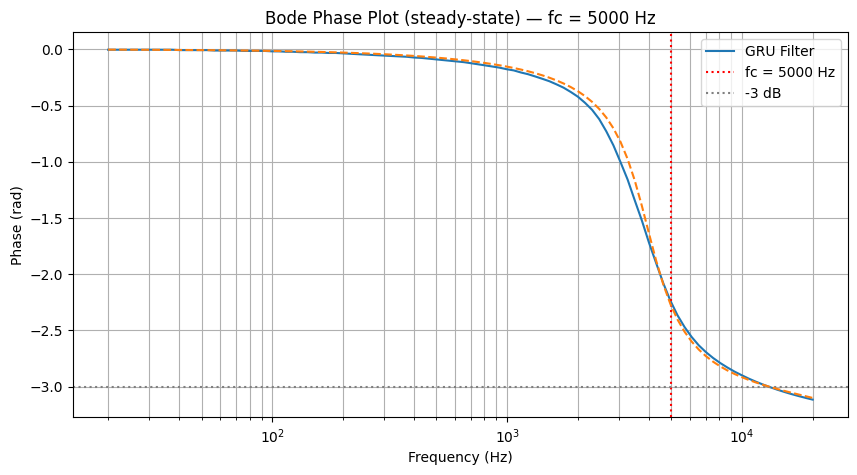

In [ ]:
import torch
import importlib
import analysis_tools as at

importlib.reload(at)
hidden_size = 128
num_layers = 2
buffer_size = 128
sample_rate = 48000
checkpoint_folder = "checkpoints-8"
dataset_folder = "dataset-1"
dataset_size = 599

state = torch.load(
    "multi_scale_spectrogram_loss/best.pt", map_location=torch.device("cpu")
)
# Strip the _orig_mod. prefix added by torch.compile
state_dict = {
    k.replace("_orig_mod.", ""): v for k, v in state["model_state_dict"].items()
}

filter_rnn = LowpassRNN(hidden_size, num_layers)
filter_rnn.load_state_dict(state_dict)
filter_rnn.eval()
order = 2
for fc in [100, 256, 750, 1000, 5000]:
    print(fc)
    # plot_bode_so(filter_rnn, fc, buffer_size, sample_rate, buffer_count=50)
    fig, axes = at.plot_bode_GRU(filter_rnn, fc, buffer_size, sample_rate, show=False,plot_type="gain")
    at.plot_cheby_into(axes, fc, order, 5, sample_rate, plot_type="gain")
    fig.show()

    fig, axes = at.plot_bode_GRU(
        filter_rnn, fc, buffer_size, sample_rate, show=False, plot_type="phase"
    )
    at.plot_cheby_into(axes, fc, order, 5, sample_rate, plot_type="phase")
    fig.show()

In [51]:
from torch import Tensor
from torch import nn
from create_dataset import exponential_sweep, normalize_freq, bandlimited_white_noise
from scipy.signal import cheby1, filtfilt
data_idx = 5
buffer_size = 512
dataset_folder = "dataset-0"

fc = 1000
fc_norm = normalize_freq(fc, sample_rate)

# x = exponential_sweep(48000, 20, 5000, 48000)
x = np.load("multi_scale_spectrogram_loss/input-1.npy")
fc_norm = x[-1]
x = x[:-1]
# x = bandlimited_white_noise(48000, sample_rate, 20, 20000, False)

b, a = cheby1(order, 5, 100, btype="low", fs=sample_rate)

y_pred = run_inference(
    filter_rnn, x, fc_norm=fc_norm, buffer_size=buffer_size, sample_rate=sample_rate
)

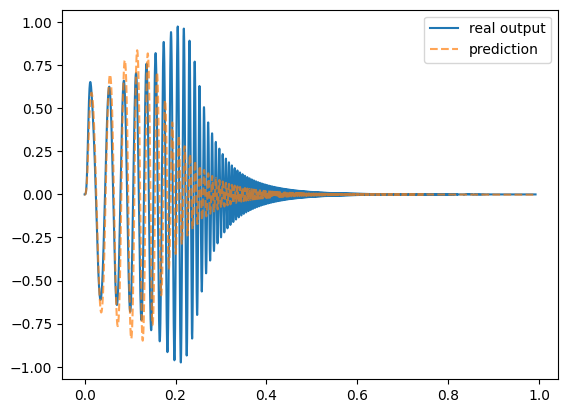

In [53]:
import matplotlib.pyplot as plt
from scipy.signal import lfilter
y = lfilter(b, a, x).astype(np.float32)

N = len(y_pred)
t = np.linspace(0, N/sample_rate, N)

plt.figure()
# plt.plot(t, x[:N], label="input")
plt.plot(t, y[:N], label="real output")
plt.plot(t, y_pred, label="prediction", linestyle="--", alpha=0.7)
plt.legend(loc="best")
plt.show()

## ONNX Runtime inference test

In [ ]:
import onnx

model = onnx.load("lowpass_rnn2.onnx")
for inp in model.graph.input:
    print(inp.name, inp.type.tensor_type.shape)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import onnxruntime as ort
import numpy as np

hidden_size = 64
num_layers = 2
buffer_size = 96
sample_rate = 48000

state = torch.load("lowpass_rnn.pt", map_location=torch.device("cpu"))
filter_rnn = LowpassRNN(hidden_size, num_layers)
filter_rnn.load_state_dict(state)
filter_rnn.eval()

input_idx = 9
dataset_idx = 10
x = np.load("dataset-{}/inputs/input-{}.npy".format(dataset_idx, input_idx))
y = np.load("dataset-{}/expected/expected-{}.npy".format(dataset_idx, input_idx))

y_pred = np.load("onnx_inference_test/output-{}.npy".format(input_idx))
y_pred_py = run_inference(
    filter_rnn, x[:-1], fc_norm=x[-1], buffer_size=96, sample_rate=sample_rate
)

print(x.shape)
print(y.shape)
print(y_pred.shape)
t = np.arange(len(y))
m = min(len(t), len(y_pred))

plt.figure()
plt.plot(t, x[:m], label="signal")
plt.plot(t, y, label="filtered signal")
plt.plot(t[:m], y_pred[:m], label="predicted filtered signal (onnx)")
plt.plot(t[:m], y_pred_py[:m], label="predicted filtered signal (pytorch)")
plt.legend(loc="lower left")
plt.show()